# 🥇 01 — Bronze Layer (RAW → Bronze)

**Pipeline:** IBM Cloud Object Storage · Medallion Architecture  
**Autor:** Federico Pfund  
**Fecha:** Abril 2026  

---

## Objetivo

Ingestar archivos CSV crudos desde el bucket **RAW** (`datalake-raw-us-south`), aplicar:

1. **Validación de schema** — Tipos de datos forzados según definición.
2. **Filtrado de nulos** — Eliminación de registros con claves primarias nulas.
3. **Deduplicación** — Por claves naturales de negocio.
4. **Columnas de auditoría** — `_bronze_ingested_at`, `_bronze_source_file`.

Y persistir en formato **Parquet** en el bucket **Bronze** (`datalake-bronze-us-south`).

---

## Tablas Procesadas

| # | Tabla | CSV Fuente | Claves de Deduplicación | Dominio |
|---|-------|-----------|------------------------|---------|
| 1 | `categoria` | Categoria.csv | Cod_Categoria | Retail |
| 2 | `subcategoria` | Subcategoria.csv | Cod_SubCategoria | Retail |
| 3 | `producto` | Producto.csv | Cod_Producto | Retail |
| 4 | `ventasinternet` | VentasInternet.csv | NumeroOrden, Cod_Producto | Retail |
| 5 | `sucursales` | Sucursales.csv | Cod_Sucursal | Retail |
| 6 | `factmine` | FactMine.csv | TruckID, ProjectID, Date | Minería |
| 7 | `mine` | Mine.csv | TruckID, ProjectID, OperatorID, Date | Minería |

---
## 1. Inicialización del Entorno Spark

In [2]:
# ============================================================================
# INICIALIZACIÓN: SparkSession + dependencias
# ----------------------------------------------------------------------------
# - Carga config.py con credenciales COS/Db2 y builder de Spark.
# - Paquetes Maven: hadoop-aws (S3A), aws-java-sdk, db2 jcc, delta-core.
# - Librerías de visualización: matplotlib + seaborn.
# ============================================================================
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from config import build_spark, cos_path, BUCKETS

from pyspark.sql.types import *
from pyspark.sql import functions as F
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# -- Estilo global de gráficos --
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

# -- Crear sesión Spark --
spark = build_spark('Bronze-Layer')
print(f'\u2705 SparkSession activa | Versi\u00f3n: {spark.version}')
print(f'   App Name   : {spark.sparkContext.appName}')
print(f'   Master     : {spark.sparkContext.master}')
print(f'   Executors  : {spark.sparkContext.defaultParallelism}')

26/04/20 08:39:58 WARN Utils: Your hostname, codespaces-a19825 resolves to a loopback address: 127.0.0.1; using 10.0.1.114 instead (on interface eth0)
26/04/20 08:39:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/workspaces/data-engineer/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/codespace/.ivy2/cache
The jars for the packages stored in: /home/codespace/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
com.ibm.db2#jcc added as a dependency
io.delta#delta-core_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-8421c90a-b9de-409d-8eec-3100344f7294;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
	found com.ibm.db2#jcc;11.5.9.0 in central
	found io.delta#delta-core_2.12;2.3.0 in central
	found io.delta#delta-storage;2.3.0 in central
	found org.antlr#antlr4-runtime;4.8 in central
:: resolution report :: resolve 821ms :: artifacts dl 22ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	com.ibm.db2#jcc;11.5.9.0 from central in [default

✅ SparkSession activa | Versión: 3.5.4
   App Name   : Bronze-Layer
   Master     : local[*]
   Executors  : 2


---
## 2. Definición de Schemas y Configuración de Tablas

Los schemas se definen explícitamente para **evitar inferencia automática** y garantizar consistencia de tipos.  
Cada tabla define sus claves de deduplicación (natural business keys).

In [2]:
# ============================================================================
# SCHEMAS: Definición explícita de tipos (equivalente a CsvSchemas.scala)
# ============================================================================

schemas = {
    # ---------- RETAIL ----------
    'Categoria.csv': StructType([
        StructField('Cod_Categoria', IntegerType(), False),
        StructField('Categoria', StringType(), False),
    ]),
    'Subcategoria.csv': StructType([
        StructField('Cod_SubCategoria', IntegerType(), False),
        StructField('SubCategoria', StringType(), False),
        StructField('Cod_Categoria', IntegerType(), False),
    ]),
    'Producto.csv': StructType([
        StructField('Cod_Producto', IntegerType(), False),
        StructField('Producto', StringType(), False),
        StructField('Cod_SubCategoria', IntegerType(), False),
        StructField('Color', StringType(), True),
    ]),
    'VentasInternet.csv': StructType([
        StructField('Cod_Producto', IntegerType(), False),
        StructField('Cod_Cliente', IntegerType(), False),
        StructField('Cod_Territorio', IntegerType(), True),
        StructField('NumeroOrden', StringType(), False),
        StructField('Cantidad', IntegerType(), False),
        StructField('PrecioUnitario', DoubleType(), False),
        StructField('CostoUnitario', DoubleType(), False),
        StructField('Impuesto', DoubleType(), True),
        StructField('Flete', DoubleType(), True),
        StructField('FechaOrden', TimestampType(), True),
        StructField('FechaEnvio', TimestampType(), True),
        StructField('FechaVencimiento', TimestampType(), True),
        StructField('Cod_Promocion', IntegerType(), True),
    ]),
    'Sucursales.csv': StructType([
        StructField('Cod_Sucursal', IntegerType(), False),
        StructField('Cod_Sucursal_PK', IntegerType(), True),
        StructField('Sucursal', StringType(), False),
        StructField('Latitud', DoubleType(), True),
        StructField('Longitud', DoubleType(), True),
    ]),
    # ---------- MINER\u00cdA ----------
    'FactMine.csv': StructType([
        StructField('TruckID', IntegerType(), False),
        StructField('ProjectID', IntegerType(), False),
        StructField('OperatorID', IntegerType(), True),
        StructField('TotalOreMined', DoubleType(), True),
        StructField('TotalWasted', DoubleType(), True),
        StructField('Date', StringType(), True),
    ]),
    'Mine.csv': StructType([
        StructField('TruckID', IntegerType(), False),
        StructField('Truck', StringType(), True),
        StructField('ProjectID', IntegerType(), False),
        StructField('Country', StringType(), True),
        StructField('OperatorID', IntegerType(), False),
        StructField('FirstName', StringType(), True),
        StructField('LastName', StringType(), True),
        StructField('Age', IntegerType(), True),
        StructField('TotalOreMined', DoubleType(), True),
        StructField('TotalWasted', DoubleType(), True),
        StructField('Date', StringType(), True),
    ]),
}

# ============================================================================
# BRONZE_TABLES: (csv_file, dedup_keys, table_name)
# ============================================================================
BRONZE_TABLES = [
    ('Categoria.csv',       ['Cod_Categoria'],                               'categoria'),
    ('Subcategoria.csv',    ['Cod_SubCategoria'],                            'subcategoria'),
    ('Producto.csv',        ['Cod_Producto'],                                'producto'),
    ('VentasInternet.csv',  ['NumeroOrden', 'Cod_Producto'],                 'ventasinternet'),
    ('Sucursales.csv',      ['Cod_Sucursal'],                                'sucursales'),
    ('FactMine.csv',        ['TruckID', 'ProjectID', 'Date'],               'factmine'),
    ('Mine.csv',            ['TruckID', 'ProjectID', 'OperatorID', 'Date'],  'mine'),
]

print(f'\u2705 {len(BRONZE_TABLES)} tablas configuradas para ingesta Bronze')
print(f'   Schemas definidos: {list(schemas.keys())}')

✅ 7 tablas configuradas para ingesta Bronze
   Schemas definidos: ['Categoria.csv', 'Subcategoria.csv', 'Producto.csv', 'VentasInternet.csv', 'Sucursales.csv', 'FactMine.csv', 'Mine.csv']


---
## 3. Exploración de Datos RAW (Pre-Ingesta)

Antes de transformar, inspeccionamos los datos crudos para entender su estado actual:  
volumen, nulos, duplicados y tipos.

In [3]:
# ============================================================================
# EXPLORACIÓN: Lectura previa de cada CSV y análisis de calidad
# ============================================================================
exploration_data = []

for csv_file, dedup_keys, table_name in BRONZE_TABLES:
    raw_path = f"s3a://{BUCKETS['raw']}/retail/{csv_file}"
    df = spark.read.csv(raw_path, header=True, schema=schemas[csv_file]).cache()
    
    total_rows = df.count()
    total_cols = len(df.columns)
    
    # Contar nulos por columna (una sola pasada en vez de N acciones)
    null_expr = [F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns]
    null_row = df.agg(*null_expr).first()
    null_counts = {c: null_row[c] for c in df.columns if null_row[c] and null_row[c] > 0}
    
    # Contar duplicados por claves naturales
    dedup_count = df.dropDuplicates(dedup_keys).count()
    duplicates = total_rows - dedup_count
    
    df.unpersist()
    
    exploration_data.append({
        'Tabla': table_name,
        'CSV': csv_file,
        'Filas': total_rows,
        'Columnas': total_cols,
        'Duplicados': duplicates,
        'Cols_con_Nulos': len(null_counts),
        'Detalle_Nulos': str(null_counts) if null_counts else '-',
    })

# -- Mostrar resumen como tabla --
df_explore = pd.DataFrame(exploration_data)
print('\n🔍 RESUMEN DE DATOS RAW\n')
display(df_explore[['Tabla', 'CSV', 'Filas', 'Columnas', 'Duplicados', 'Cols_con_Nulos']])

26/04/12 16:58:00 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties



🔍 RESUMEN DE DATOS RAW



,Tabla,CSV,Filas,Columnas,Duplicados,Cols_con_Nulos
0,categoria,Categoria.csv,4,2,0,0
1,subcategoria,Subcategoria.csv,37,3,0,0
2,producto,Producto.csv,319,4,0,0
3,ventasinternet,VentasInternet.csv,47263,13,0,0
4,sucursales,Sucursales.csv,11,5,0,0
5,factmine,FactMine.csv,49,6,0,0
6,mine,Mine.csv,15205,11,0,0


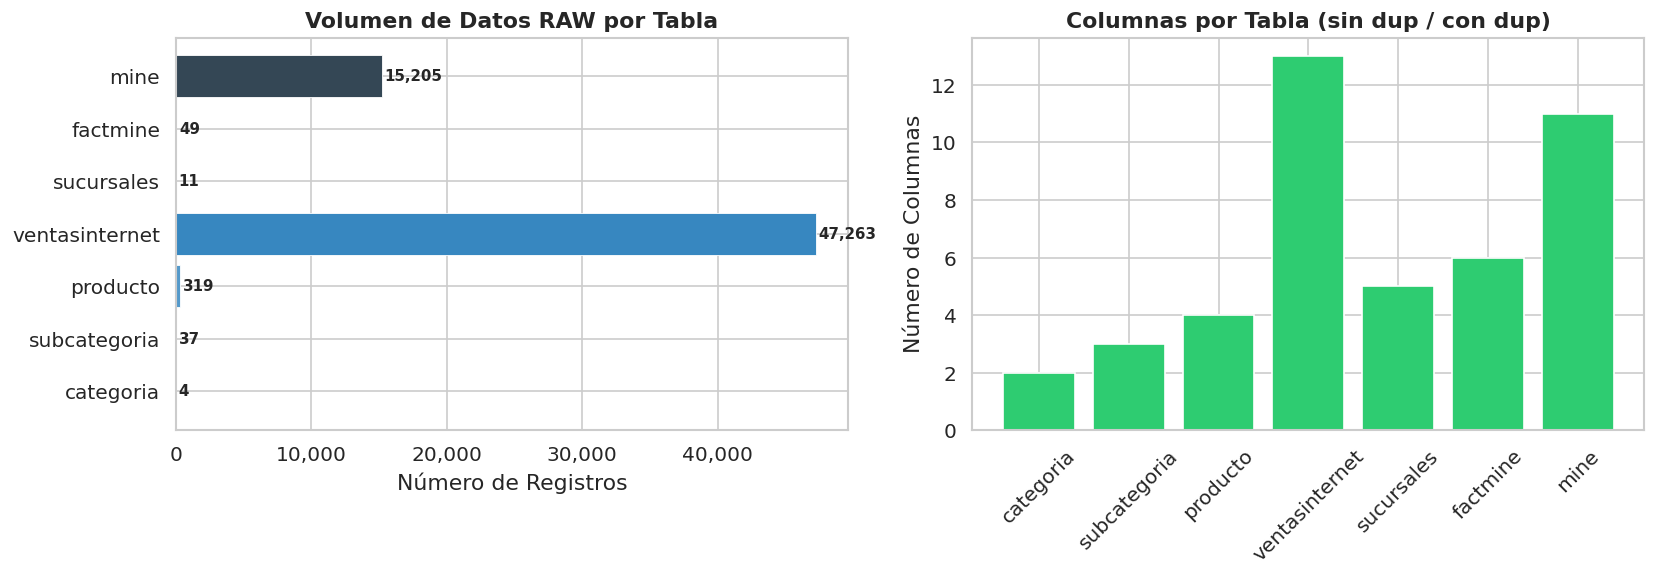

In [4]:
# ============================================================================
# GRÁFICO: Volumen de registros por tabla RAW + Calidad de columnas
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Panel 1: Barras horizontales de volumen --
colors = sns.color_palette('Blues_d', len(df_explore))
bars = axes[0].barh(
    df_explore['Tabla'], 
    df_explore['Filas'], 
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_xlabel('Número de Registros')
axes[0].set_title('Volumen de Datos RAW por Tabla', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, df_explore['Filas']):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')

# -- Panel 2: Columnas por tabla coloreadas por calidad --
palette = ['#2ecc71' if d == 0 else '#e74c3c' for d in df_explore['Duplicados']]
axes[1].bar(df_explore['Tabla'], df_explore['Columnas'], color=palette, edgecolor='white')
axes[1].set_ylabel('Número de Columnas')
axes[1].set_title('Columnas por Tabla (sin dup / con dup)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================================
# DETALLE: Schema y primeras filas de cada tabla RAW
# ============================================================================
for csv_file, dedup_keys, table_name in BRONZE_TABLES:
    raw_path = f"s3a://{BUCKETS['raw']}/retail/{csv_file}"
    df = spark.read.csv(raw_path, header=True, schema=schemas[csv_file])
    
    print(f'\n{"="*70}')
    print(f'  {table_name.upper()} ({csv_file})')
    print(f'     Filas: {df.count():,} | Columnas: {len(df.columns)}')
    print(f'     Dedup keys: {dedup_keys}')
    print(f'{"="*70}')
    
    # Schema detallado
    print('\n   Schema:')
    for field in df.schema.fields:
        nullable = '\u2705 nullable' if field.nullable else '\u274c NOT NULL'
        print(f'     {field.name:<25} {str(field.dataType):<20} {nullable}')
    
    # Estad\u00edsticas descriptivas para columnas num\u00e9ricas
    numeric_cols = [f.name for f in df.schema.fields 
                    if isinstance(f.dataType, (IntegerType, DoubleType))]
    if numeric_cols:
        print('\n Estad\u00edsticas num\u00e9ricas:')
        df.select(numeric_cols).summary('count', 'min', 'max', 'mean').show(truncate=False)
    
    # Muestra de primeras 5 filas
    print('   Muestra (5 filas):')
    df.show(5, truncate=30)


  CATEGORIA (Categoria.csv)
     Filas: 4 | Columnas: 2
     Dedup keys: ['Cod_Categoria']

   Schema:
     Cod_Categoria             IntegerType()        ✅ nullable
     Categoria                 StringType()         ✅ nullable

 Estadísticas numéricas:
+-------+-------------+
|summary|Cod_Categoria|
+-------+-------------+
|count  |4            |
|min    |1            |
|max    |4            |
|mean   |2.5          |
+-------+-------------+

   Muestra (5 filas):
+-------------+----------+
|Cod_Categoria| Categoria|
+-------------+----------+
|            1| Bicicleta|
|            2|Componente|
|            3|    Prenda|
|            4| Accesorio|
+-------------+----------+


  SUBCATEGORIA (Subcategoria.csv)
     Filas: 37 | Columnas: 3
     Dedup keys: ['Cod_SubCategoria']

   Schema:
     Cod_SubCategoria          IntegerType()        ✅ nullable
     SubCategoria              StringType()         ✅ nullable
     Cod_Categoria             IntegerType()        ✅ nullable

 Estadís

     Filas: 47,263 | Columnas: 13
     Dedup keys: ['NumeroOrden', 'Cod_Producto']

   Schema:
     Cod_Producto              IntegerType()        ✅ nullable
     Cod_Cliente               IntegerType()        ✅ nullable
     Cod_Territorio            IntegerType()        ✅ nullable
     NumeroOrden               StringType()         ✅ nullable
     Cantidad                  IntegerType()        ✅ nullable
     PrecioUnitario            DoubleType()         ✅ nullable
     CostoUnitario             DoubleType()         ✅ nullable
     Impuesto                  DoubleType()         ✅ nullable
     Flete                     DoubleType()         ✅ nullable
     FechaOrden                TimestampType()      ✅ nullable
     FechaEnvio                TimestampType()      ✅ nullable
     FechaVencimiento          TimestampType()      ✅ nullable
     Cod_Promocion             IntegerType()        ✅ nullable

 Estadísticas numéricas:


+-------+-----------------+------------------+-----------------+--------+-----------------+------------------+-----------------+------------------+------------------+
|summary|Cod_Producto     |Cod_Cliente       |Cod_Territorio   |Cantidad|PrecioUnitario   |CostoUnitario     |Impuesto         |Flete             |Cod_Promocion     |
+-------+-----------------+------------------+-----------------+--------+-----------------+------------------+-----------------+------------------+------------------+
|count  |47263            |47263             |47263            |47263   |47263            |47263             |47263            |47263             |47263             |
|min    |214              |11000             |1                |1       |3.99             |1.4923            |0.3192           |0.0998            |1                 |
|max    |606              |29483             |10               |1       |3578.27          |2171.2942         |286.2616         |89.4568           |14                

---
## 4. Procesamiento Bronze

Para cada tabla se ejecuta el pipeline:

```
RAW CSV → Schema Enforcement → Null Filter → Deduplicación → Audit Columns → Parquet (COS Bronze)
```

In [11]:
# ============================================================================
# PROCESAMIENTO BRONZE: Ingesta, limpieza y persistencia
# ----------------------------------------------------------------------------
# Cada tabla pasa por 5 pasos:
#   1. Lectura CSV con schema enforcement
#   2. Filtrado de registros con claves primarias nulas
#   3. Deduplicaci\u00f3n por claves naturales de negocio
#   4. Adici\u00f3n de columnas de auditor\u00eda (_bronze_ingested_at, _bronze_source_file)
#   5. Escritura en formato Parquet al bucket COS Bronze
# ============================================================================
results = []
start_time = datetime.now()

for csv_file, dedup_keys, table_name in BRONZE_TABLES:
    t0 = datetime.now()
    raw_path = f"s3a://{BUCKETS['raw']}/retail/{csv_file}"
    bronze_path = cos_path('bronze', table_name)

    # Paso 1: Lectura con schema enforcement
    df = spark.read.csv(raw_path, header=True, schema=schemas[csv_file])
    raw_count = df.count()

    # Paso 2: Filtrar registros con claves primarias nulas
    for key in dedup_keys:
        df = df.filter(F.col(key).isNotNull())
    after_null_filter = df.count()
    null_rejected = raw_count - after_null_filter

    # Paso 3: Deduplicaci\u00f3n por claves naturales
    df = df.dropDuplicates(dedup_keys)
    after_dedup = df.count()
    dedup_rejected = after_null_filter - after_dedup

    # Paso 4: Agregar columnas de auditor\u00eda
    df = (df
        .withColumn('_bronze_ingested_at', F.current_timestamp())
        .withColumn('_bronze_source_file', F.lit(csv_file))
    )

    # Paso 5: Escribir Parquet en COS Bronze
    df.write.mode('overwrite').parquet(bronze_path)
    
    elapsed = (datetime.now() - t0).total_seconds()
    bronze_count = after_dedup

    results.append({
        'Tabla': table_name,
        'RAW': raw_count,
        'Post_Null_Filter': after_null_filter,
        'Nulos_Eliminados': null_rejected,
        'Post_Dedup': after_dedup,
        'Duplicados_Eliminados': dedup_rejected,
        'Bronze_Final': bronze_count,
        'Rechazados_Total': raw_count - bronze_count,
        'Pct_Retencion': round(bronze_count / raw_count * 100, 1) if raw_count > 0 else 0,
        'Tiempo_seg': round(elapsed, 1),
    })
    
    status = '\u2705' if bronze_count == raw_count else '\u26a0\ufe0f'
    print(f'  {status} {table_name:<16} | RAW: {raw_count:>6,} \u2192 Bronze: {bronze_count:>6,} '
          f'| -{null_rejected} nulos, -{dedup_rejected} duplicados | {elapsed:.1f}s')

total_time = (datetime.now() - start_time).total_seconds()
total_raw = sum(r['RAW'] for r in results)
total_bronze = sum(r['Bronze_Final'] for r in results)
total_rejected = sum(r['Rechazados_Total'] for r in results)

print(f'\n{"="*75}')
print(f'   BRONZE LAYER COMPLETA')
print(f'     Tablas procesadas : {len(results)}')
print(f'     Registros RAW     : {total_raw:,}')
print(f'     Registros Bronze  : {total_bronze:,}')
print(f'     Registros perdidos: {total_rejected:,}')
print(f'     Tiempo total      : {total_time:.1f}s')
print(f'{"="*75}')

  ✅ categoria        | RAW:      4 → Bronze:      4 | -0 nulos, -0 duplicados | 5.7s


  ✅ subcategoria     | RAW:     37 → Bronze:     37 | -0 nulos, -0 duplicados | 5.6s


  ✅ producto         | RAW:    319 → Bronze:    319 | -0 nulos, -0 duplicados | 5.1s


  ✅ ventasinternet   | RAW: 47,263 → Bronze: 47,263 | -0 nulos, -0 duplicados | 10.1s


  ✅ sucursales       | RAW:     11 → Bronze:     11 | -0 nulos, -0 duplicados | 6.1s


  ✅ factmine         | RAW:     49 → Bronze:     49 | -0 nulos, -0 duplicados | 5.0s


  ✅ mine             | RAW: 15,205 → Bronze: 15,205 | -0 nulos, -0 duplicados | 6.1s

   BRONZE LAYER COMPLETA
     Tablas procesadas : 7
     Registros RAW     : 62,888
     Registros Bronze  : 62,888
     Registros perdidos: 0
     Tiempo total      : 43.8s


---
## 5. Resultados y Visualización

In [9]:
# ============================================================================
# TABLA DE RESULTADOS: Resumen detallado del procesamiento Bronze
# ============================================================================
df_results = pd.DataFrame(results)

styled = (df_results
    .style
    .set_caption('Resultados de Ingesta Bronze')
    .format({
        'RAW': '{:,}',
        'Post_Null_Filter': '{:,}',
        'Post_Dedup': '{:,}',
        'Bronze_Final': '{:,}',
        'Nulos_Eliminados': '{:,}',
        'Duplicados_Eliminados': '{:,}',
        'Rechazados_Total': '{:,}',
        'Pct_Retencion': '{:.1f}%',
        'Tiempo_seg': '{:.1f}s',
    })
    .bar(subset=['Bronze_Final'], color='#5dade2', vmin=0)
    .bar(subset=['Pct_Retencion'], color='#2ecc71', vmin=0, vmax=100)
    .set_properties(**{'text-align': 'center'})
)
display(styled)

,Tabla,RAW,Post_Null_Filter,Nulos_Eliminados,Post_Dedup,Duplicados_Eliminados,Bronze_Final,Rechazados_Total,Pct_Retencion,Tiempo_seg
0,categoria,4,4,0,4,0,4,0,100.0%,12.8s
1,subcategoria,37,37,0,37,0,37,0,100.0%,6.5s
2,producto,319,319,0,319,0,319,0,100.0%,5.6s
3,ventasinternet,"47,263","47,263",0,"47,263",0,"47,263",0,100.0%,11.7s
4,sucursales,11,11,0,11,0,11,0,100.0%,5.8s
5,factmine,49,49,0,49,0,49,0,100.0%,7.2s
6,mine,"15,205","15,205",0,"15,205",0,"15,205",0,100.0%,9.7s


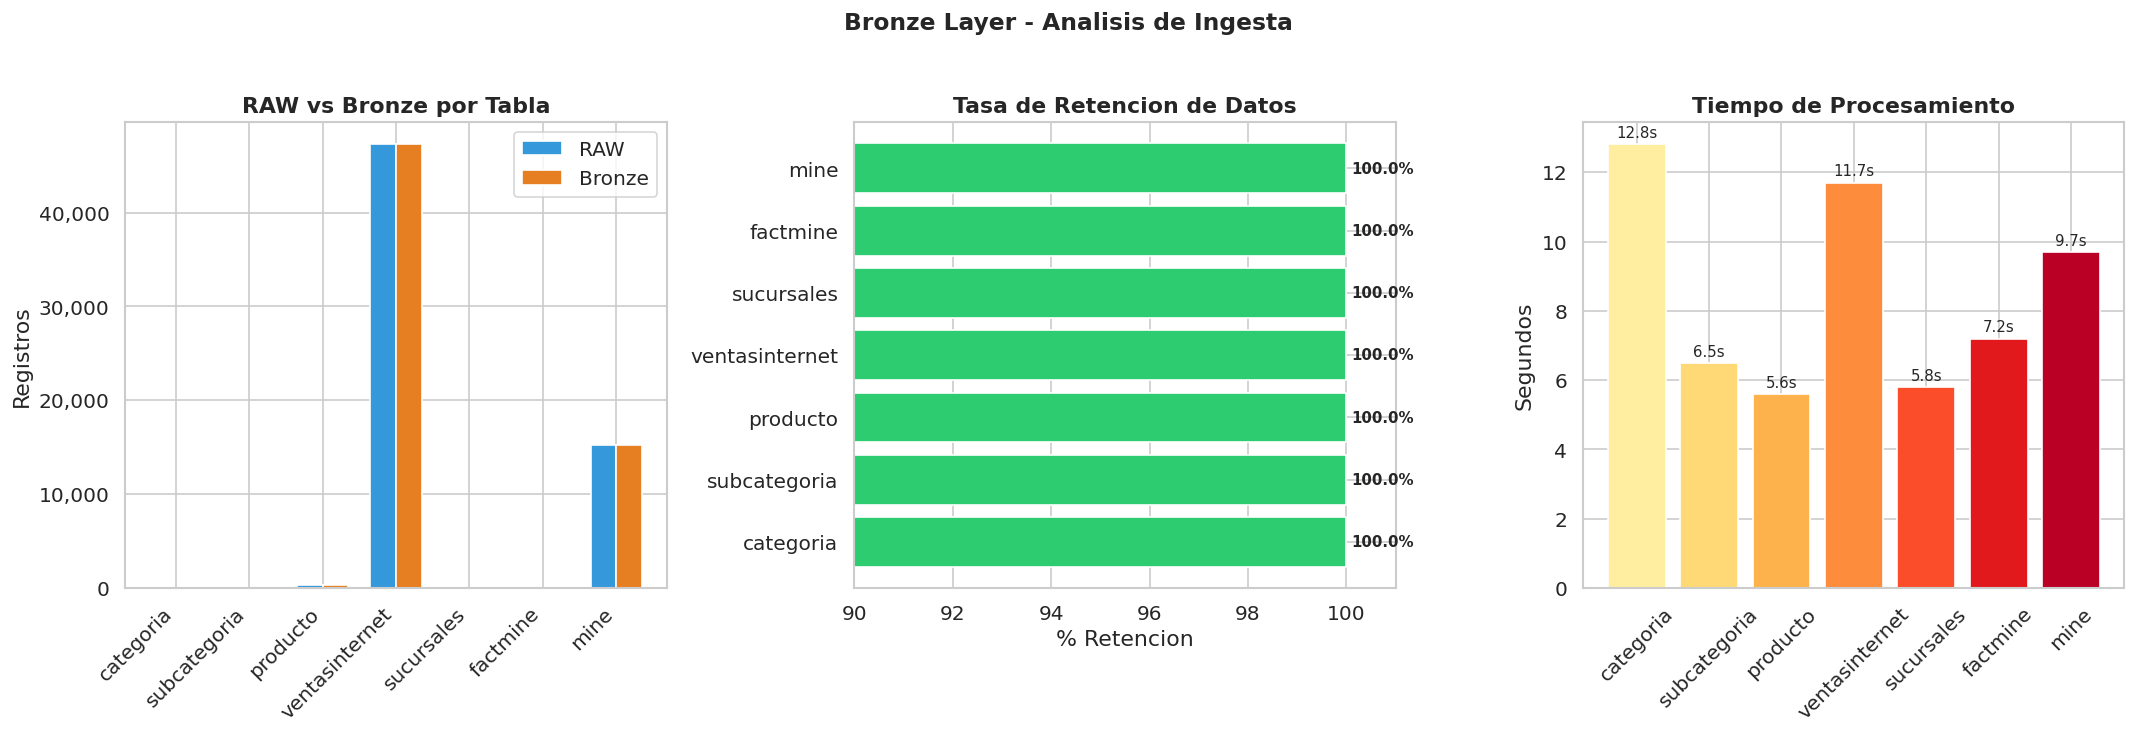

In [10]:
# ============================================================================
# GRÁFICO 1: Panel triple - RAW vs Bronze, Retención, Tiempos
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# -- Panel 1: RAW vs Bronze --
x = range(len(df_results))
width = 0.35
axes[0].bar([i - width/2 for i in x], df_results['RAW'], width, 
            label='RAW', color='#3498db', edgecolor='white')
axes[0].bar([i + width/2 for i in x], df_results['Bronze_Final'], width, 
            label='Bronze', color='#e67e22', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results['Tabla'], rotation=45, ha='right')
axes[0].set_ylabel('Registros')
axes[0].set_title('RAW vs Bronze por Tabla', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# -- Panel 2: % Retención --
colors_ret = ['#2ecc71' if p == 100 else '#f39c12' if p >= 95 else '#e74c3c' 
              for p in df_results['Pct_Retencion']]
bars3 = axes[1].barh(df_results['Tabla'], df_results['Pct_Retencion'], 
                      color=colors_ret, edgecolor='white')
axes[1].set_xlim(90, 101)
axes[1].set_xlabel('% Retencion')
axes[1].set_title('Tasa de Retencion de Datos', fontweight='bold')
for bar, val in zip(bars3, df_results['Pct_Retencion']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# -- Panel 3: Tiempo de procesamiento --
axes[2].bar(df_results['Tabla'], df_results['Tiempo_seg'], 
            color=sns.color_palette('YlOrRd', len(df_results)), edgecolor='white')
axes[2].set_ylabel('Segundos')
axes[2].set_title('Tiempo de Procesamiento', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_results['Tiempo_seg']):
    axes[2].text(i, v + 0.2, f'{v:.1f}s', ha='center', fontsize=9)

plt.suptitle('Bronze Layer - Analisis de Ingesta', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

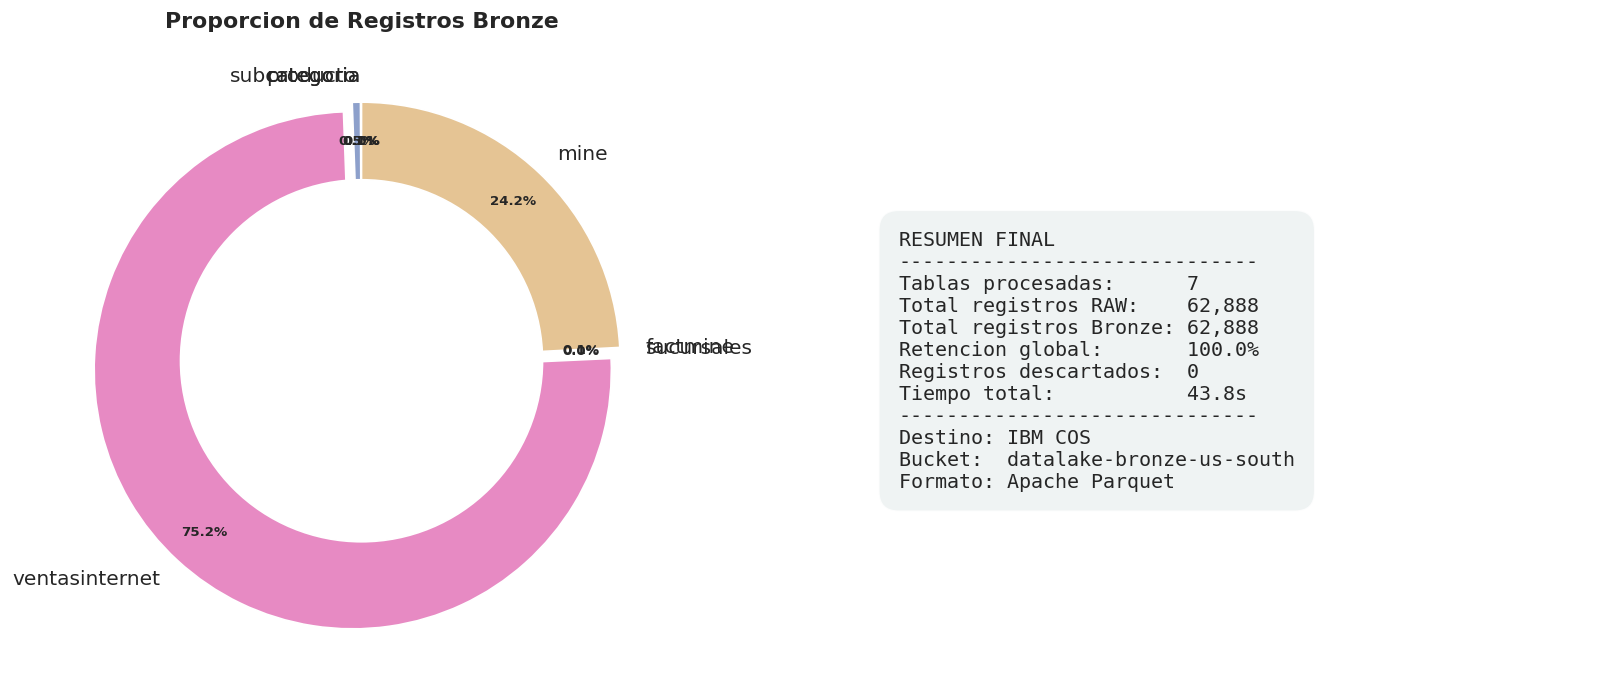


Bronze Layer finalizada exitosamente. Continuar con 02_silver_layer.ipynb


In [13]:
# ============================================================================
# GRÁFICO 2: Proporción de volumen + Resumen final
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Donut chart: proporción de registros --
explode = [0.05 if v == df_results['Bronze_Final'].max() else 0 
           for v in df_results['Bronze_Final']]
wedges, texts, autotexts = axes[0].pie(
    df_results['Bronze_Final'], labels=df_results['Tabla'],
    autopct='%1.1f%%', explode=explode,
    colors=sns.color_palette('Set2', len(df_results)),
    startangle=90, pctdistance=0.85,
)
for t in autotexts:
    t.set_fontsize(8)
    t.set_fontweight('bold')
axes[0].add_artist(plt.Circle((0, 0), 0.70, fc='white'))
axes[0].set_title('Proporcion de Registros Bronze', fontweight='bold')

# -- Panel texto: resumen --
separator = '-' * 30
summary_text = (
    f'RESUMEN FINAL\n'
    f'{separator}\n'
    f'Tablas procesadas:      {len(results)}\n'
    f'Total registros RAW:    {total_raw:,}\n'
    f'Total registros Bronze: {total_bronze:,}\n'
    f'Retencion global:       {total_bronze/total_raw*100:.1f}%\n'
    f'Registros descartados:  {total_rejected:,}\n'
    f'Tiempo total:           {total_time:.1f}s\n'
    f'{separator}\n'
    f'Destino: IBM COS\n'
    f'Bucket:  {BUCKETS["bronze"]}\n'
    f'Formato: Apache Parquet'
)
axes[1].text(0.1, 0.5, summary_text, transform=axes[1].transAxes,
             fontsize=12, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=1', facecolor='#ecf0f1', alpha=0.8))
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('\nBronze Layer finalizada exitosamente. Continuar con 02_silver_layer.ipynb')

# 01 - Bronze Layer (RAW → Bronze)
**IBM Cloud Object Storage** | Medallion Architecture

Reads raw CSV files from `datalake-raw-us-south` and writes deduplicated, schema-enforced Parquet to `datalake-bronze-us-south`.

| Table | Source CSV | Dedup Keys |
|-------|-----------|------------|
| categoria | Categoria.csv | Cod_Categoria |
| subcategoria | Subcategoria.csv | Cod_SubCategoria |
| producto | Producto.csv | Cod_Producto |
| ventasinternet | VentasInternet.csv | NumeroOrden, Cod_Producto |
| sucursales | Sucursales.csv | Cod_Sucursal |
| factmine | FactMine.csv | TruckID, ProjectID, Date |
| mine | Mine.csv | TruckID, ProjectID, OperatorID, Date |